# Flow over the Cylinder

## Import Library

In [67]:
import numpy as np
import matplotlib.pyplot as plt

## Domain Setup

In [68]:
Diameter = 1.0 # Diameter of the cylinder

Lx = 22 # Length of the domain in the x-direction (22 diameters long)
Ly = 10 # Length of the domain in the y-direction (10 diameters wide)

Nx = 220 # Number of grid points in the x-direction (10 points per diameter)
Ny = 100 # Number of grid points in the y-direction (10 points per diameter)

dx = Lx / Nx
dy = Ly / Ny

cx = 5 # x-coordinate of the cylinder center (5 diameters from the inlet)
cy = Ly / 2 # y-coordinate of the cylinder center (centered in the y-direction)
R = Diameter / 2 # Radius of the cylinder

Re = 100 # Reynolds number
Nu = 0.01 # Kinematic viscosity (arbitrary value for demonstration)
U = Re * Nu / Diameter # Inlet velocity calculated from Reynolds number
V = 0.0 # No velocity in the y-direction at the inlet

# Create the grid
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)

# Create a mask for the cylinder
cylinder_mask = (X - cx)**2 + (Y - cy)**2 <= R**2

# Create the velocity and pressure fields
u = np.zeros((Ny, Nx)) # Velocity in the x-direction
v = np.zeros((Ny, Nx)) # Velocity in the y-direction
p = np.zeros((Ny, Nx)) # Pressure field

safety_factor = 0.8
dt = safety_factor / (U/dx + U/dy + 2*Nu/dx**2 + 2*Nu/dy**2)
print(f"Time step (dt) for stability: {dt:.5f} seconds")

CFL_x = U * dt / dx
CFL_y = U * dt / dy
r = Nu * dt / dx**2

print(f"dt       = {dt:.6f}")
print(f"CFL_x    = {CFL_x:.4f}")
print(f"CFL_y    = {CFL_y:.4f}")
print(f"r        = {r:.4f}")
print(f"Combined = {CFL_x + CFL_y + 4*r:.4f}  (must be ≤ 1)")

nt = 20000  # Number of time steps
T = nt * dt  # Total simulation time
print(f"Total simulation time T = {T:.4f}")

Time step (dt) for stability: 0.03333 seconds
dt       = 0.033333
CFL_x    = 0.3333
CFL_y    = 0.3333
r        = 0.0333
Combined = 0.8000  (must be ≤ 1)
Total simulation time T = 666.6667


## Initial condition

In [69]:
# set initial conditions
u = np.full((Ny, Nx), U) # Initial velocity in the x-direction (uniform flow)
u[cylinder_mask] = 0.0 # No-slip condition on the cylinder surface
v[cylinder_mask] = 0.0 # No-slip condition on the cylinder surface

# Algorithm Per Time Step

## Apply Boundary Conditions to u, v

In [70]:
def apply_boundary_conditions(u, v, cylinder_mask):
    # Inlet boundary conditions
    u[:, 0] = U # Inlet: uniform flow
    v[:, 0] = 0.0 # Inlet: no velocity in y-direction


    # Outlet boundary conditions (Neumann condition)
    u[:, -1] = u[:, -2] # Outlet: zero gradient for velocity
    v[:, -1] = v[:, -2] # Outlet: zero gradient for velocity

    # Top and bottom boundary conditions (free-slip)
    u[0, :] = u[1, :] # Free-slip: zero gradient in y-direction
    v[0, :] = 0.0 # Free-slip: no velocity in y-direction
    u[-1, :] = u[-2, :] # Free-slip: zero gradient in y-direction
    v[-1, :] = 0.0 # Free-slip: no velocity in y-direction

    # No-slip condition on the cylinder surface
    u[cylinder_mask] = 0.0 # No-slip condition on the cylinder surface
    v[cylinder_mask] = 0.0 # No-slip condition on the cylinder surface

    return u, v

## Momentum Predictor - Compute u*, v* (momentum without pressure)

In [71]:
def momentum_predictor(u, v, p, dx, dy, dt, Nu):
    un = u.copy()
    vn = v.copy()

    u_star = un.copy()
    v_star = vn.copy()

    # Neighbours of u, v - interior points only
    u_e = un[1:-1, 2:]   # u[i, j+1]
    u_w = un[1:-1, :-2]  # u[i, j-1]
    u_n = un[2:, 1:-1]   # u[i+1, j]
    u_s = un[:-2, 1:-1]  # u[i-1, j]

    v_e = vn[1:-1, 2:]   # v[i, j+1]
    v_w = vn[1:-1, :-2]  # v[i, j-1]
    v_n = vn[2:, 1:-1]   # v[i+1, j]
    v_s = vn[:-2, 1:-1]  # v[i-1, j]

    # Convection terms - Upwind scheme
    conv_u_x = np.maximum(un[1:-1, 1:-1], 0) * (un[1:-1, 1:-1] - u_w)/dx + np.minimum(un[1:-1, 1:-1], 0) * (u_e - un[1:-1, 1:-1])/dx
    conv_u_y = np.maximum(vn[1:-1, 1:-1], 0) * (un[1:-1, 1:-1] - u_s)/dy + np.minimum(vn[1:-1, 1:-1], 0) * (u_n - un[1:-1, 1:-1])/dy
    
    conv_v_x = np.maximum(un[1:-1, 1:-1], 0) * (vn[1:-1, 1:-1] - v_w)/dx + np.minimum(un[1:-1, 1:-1], 0) * (v_e - vn[1:-1, 1:-1])/dx
    conv_v_y = np.maximum(vn[1:-1, 1:-1], 0) * (vn[1:-1, 1:-1] - v_s)/dy + np.minimum(vn[1:-1, 1:-1], 0) * (v_n - vn[1:-1, 1:-1])/dy

    conv_u = conv_u_x + conv_u_y
    conv_v = conv_v_x + conv_v_y

    # Diffusion terms (central differences)
    diff_u = Nu * (u_e - 2*un[1:-1, 1:-1] + u_w) / dx**2 + Nu * (u_n - 2*un[1:-1, 1:-1] + u_s) / dy**2
    diff_v = Nu * (v_n - 2*vn[1:-1, 1:-1] + v_s) / dy**2 + Nu * (v_e - 2*vn[1:-1, 1:-1] + v_w) / dx**2

    u_star[1:-1, 1:-1] = un[1:-1, 1:-1] + dt * (diff_u - conv_u)
    v_star[1:-1, 1:-1] = vn[1:-1, 1:-1] + dt * (diff_v - conv_v)

    return u_star, v_star

## Compute divergence b = ∇·u*

In [72]:
# compute the divergence of the intermediate velocity field
def compute_divergence(u_star, v_star, dx, dy):
    div = (u_star[1:-1, 2:] - u_star[1:-1, :-2]) / (2*dx) + (v_star[2:, 1:-1] - v_star[:-2, 1:-1]) / (2*dy)
    return div

## Connector - Pressure Poisson Solver

In [73]:
def pressure_poisson_connector(u_star, v_star, p, dx, dy, dt, rho=1.0, max_iter=20000, tol=1e-4):
    # Solve the Poisson equation iteratively
    for it in range(max_iter):
        p_old = p.copy()

        # Neighbours of p - interior points only
        p_e = p_old[1:-1, 2:]   # p[i, j+1]
        p_w = p_old[1:-1, :-2]  # p[i, j-1]
        p_n = p_old[2:, 1:-1]   # p[i+1, j]
        p_s = p_old[:-2, 1:-1]  # p[i-1, j]

        div = compute_divergence(u_star, v_star, dx, dy)

        rhs = (rho / dt) * div

        # Jacobi update for pressure
        p[1:-1, 1:-1] = (p_e + p_w) * dy**2 + (p_n + p_s) * dx**2 - rhs * dx**2 * dy**2
        p[1:-1, 1:-1] /= (2 * (dx**2 + dy**2))

        # Boundary conditions for pressure (Neumann: dp/dn=0)
        p[0, :] = p[1, :]     # dp/dy=0 at bottom
        p[-1, :] = p[-2, :]   # dp/dy=0 at top
        p[:, 0] = p[:, 1]     # dp/dx=0 at left
        p[:, -1] = p[:, -2]   # dp/dx=0 at right

        p[:, -1] = 0.0  # Poisson Pressure BC: Dirichlet condition at outlet (reference pressure)

        # Check for convergence
        if np.linalg.norm(p - p_old) < tol:
            break
    else:
        print("Pressure Poisson did not converge within the maximum iterations.")
    
    return p

## Correct: u = u* - dt·∂p/∂x,  v = v* - dt·∂p/∂y

In [74]:
def velocity_corrector(u_star, v_star, p, dx, dy, dt, rho=1.0):
    u = u_star.copy()
    v = v_star.copy()

    # Neighbours of p - interior points only
    p_e = p[1:-1, 2:]   # p[i, j+1]
    p_w = p[1:-1, :-2]  # p[i, j-1]
    p_n = p[2:, 1:-1]   # p[i+1, j]
    p_s = p[:-2, 1:-1]  # p[i-1, j]

    u[1:-1, 1:-1] = u_star[1:-1, 1:-1] - (dt/rho) * (p_e - p_w) / (2*dx)
    v[1:-1, 1:-1] = v_star[1:-1, 1:-1] - (dt/rho) * (p_n - p_s) / (2*dy)

    return u, v

## Track ${max|u^{n+1} - u^n|}$ for steady state convergence

In [75]:
def check_convergence(u, v, u_old, v_old, tol=1e-4):
    du = np.linalg.norm(u - u_old)
    dv = np.linalg.norm(v - v_old)
    return du < tol and dv < tol

## Compute Drag and Lift

In [76]:
def compute_forces(u, v, cylinder_mask, dx, dy, rho=1.0):
    Fd = -rho * np.sum(u[cylinder_mask]) * dx * dy / dt
    Fl = -rho * np.sum(v[cylinder_mask]) * dx * dy / dt
    Cd = Fd / (0.5 * rho * U**2 * Diameter)
    Cl = Fl / (0.5 * rho * U**2 * Diameter)
    return Cd, Cl

## Main Loop

In [77]:
residual_history = []
u_history = []
v_history = []
p_history = []
drag_history = []
lift_history = []

for n in range(nt):
    u_old = u.copy()
    v_old = v.copy()
    p_old = p.copy()

    u_old, v_old = apply_boundary_conditions(u_old, v_old, cylinder_mask)
    u_star, v_star = momentum_predictor(u_old, v_old, p_old, dx, dy, dt, Nu)
    p = pressure_poisson_connector(u_star, v_star, p_old, dx, dy, dt)
    u, v = velocity_corrector(u_star, v_star, p, dx, dy, dt)

    drag_coeff, lift_coeff = compute_forces(u, v, cylinder_mask, dx, dy)
    drag_history.append(drag_coeff)
    lift_history.append(lift_coeff)

    u, v = apply_boundary_conditions(u, v, cylinder_mask)

    if n % 50 == 0:
        u_history.append(u.copy())
        v_history.append(v.copy())
        p_history.append(p.copy())

    residual = np.max(np.abs(u - u_old))
    residual_history.append(residual)
    if n % 100 == 0:
        print(f"Step {n:4d} | residual = {residual:.2e}")

Pressure Poisson did not converge within the maximum iterations.
Step    0 | residual = 3.58e-01
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum itera

## Result Visualization

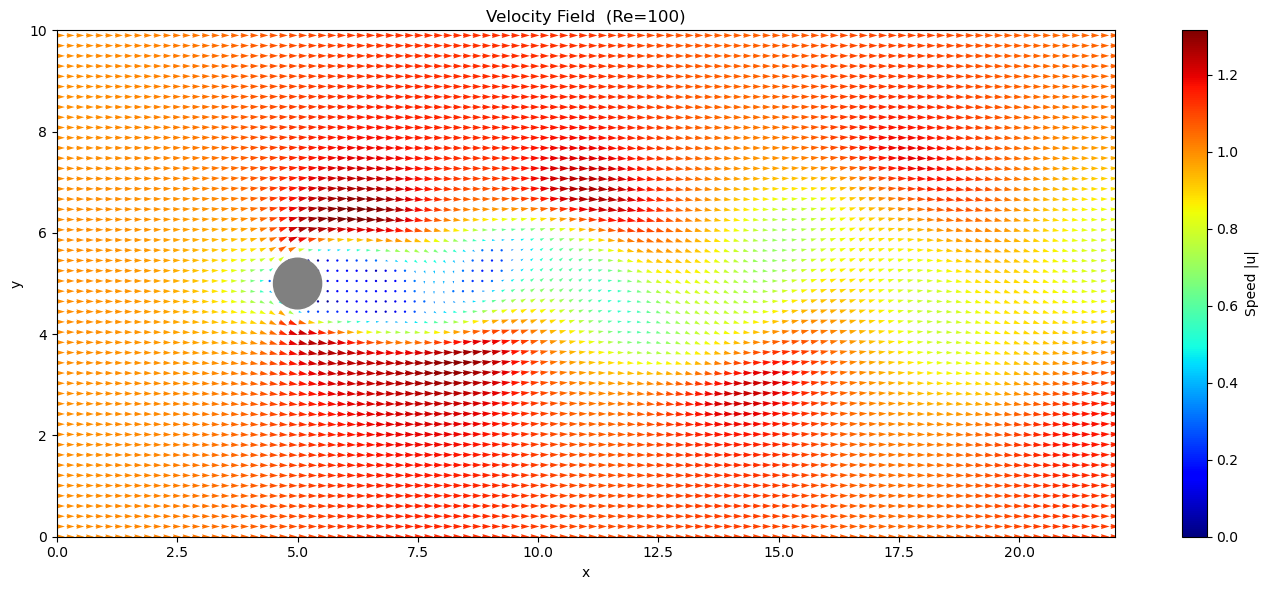

In [109]:
# Velocity Field over the cylinder
step = 2
speed = np.sqrt(u[::step, ::step]**2 + v[::step, ::step]**2)

plt.figure(figsize=(14, 6))
plt.title(f"Velocity Field  (Re={Re})")

q = plt.quiver(
    X[::step, ::step], Y[::step, ::step],
    u[::step, ::step], v[::step, ::step],
    speed,                        # color array
    cmap='jet',                   # or 'viridis', 'plasma', 'RdBu_r', etc.
    clim=[0, speed.max()]
)
plt.colorbar(q, label='Speed |u|')

cylinder = plt.Circle((cx, cy), R, color='gray', zorder=5)
plt.gca().add_patch(cylinder)
plt.xlabel('x'); plt.ylabel('y')
plt.xlim(0, Lx); plt.ylim(0, Ly)
plt.tight_layout()
plt.show()

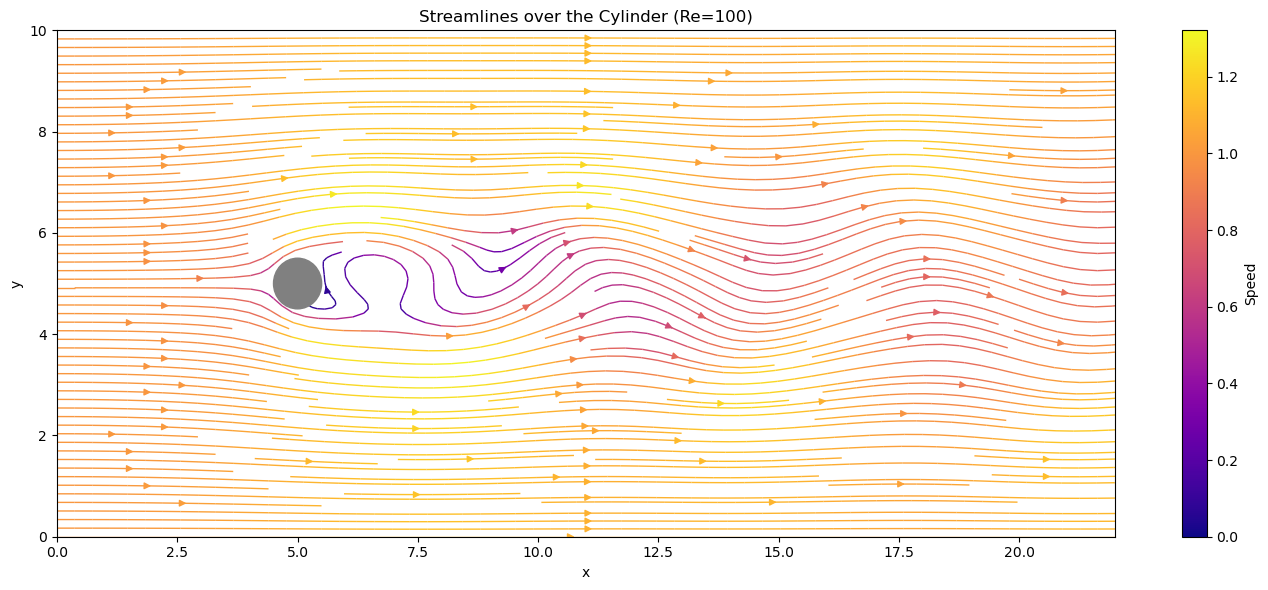

In [181]:
# Streamlines over the cylinder
speed = np.sqrt(u**2 + v**2)
plt.figure(figsize=(14, 6))
plt.title(f"Streamlines over the Cylinder (Re={Re})")
plt.streamplot(X, Y, u, v, density=2, color=speed, cmap='plasma', linewidth=1)
cylinder = plt.Circle((cx, cy), R, color='gray', zorder=5)
plt.gca().add_patch(cylinder)
plt.colorbar(label='Speed')
plt.xlabel('x'); plt.ylabel('y')
plt.xlim(0, Lx); plt.ylim(0, Ly)
plt.tight_layout()
plt.show()

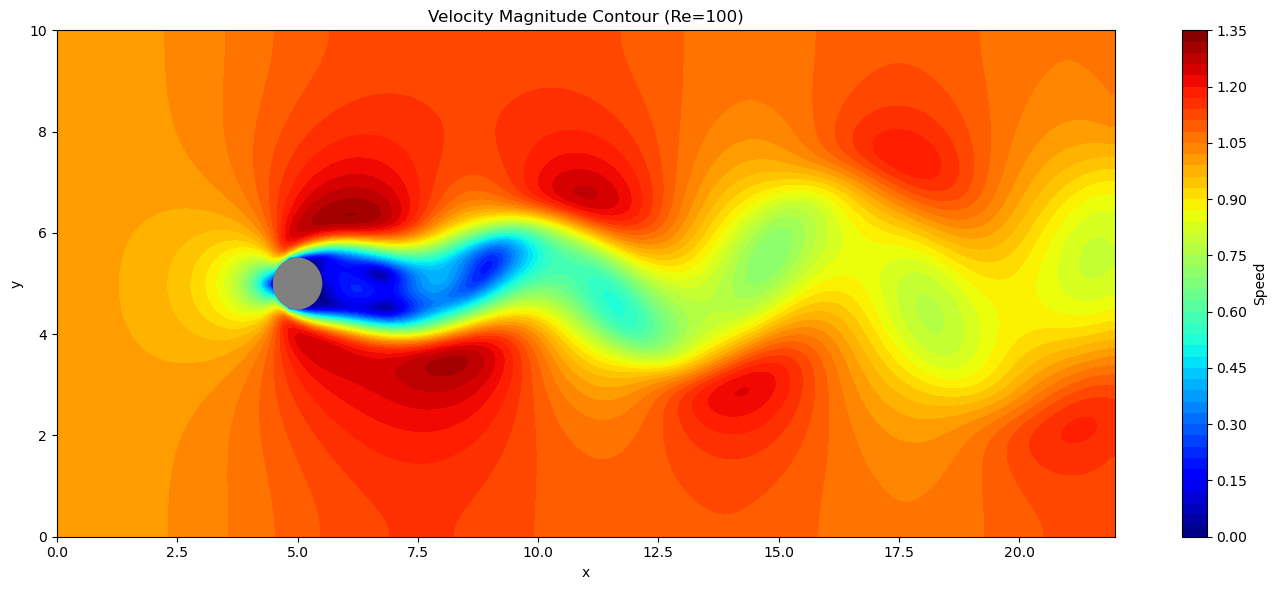

In [186]:
# velocity magnitude contour
plt.figure(figsize=(14, 6))
plt.title(f"Velocity Magnitude Contour (Re={Re})")
plt.contourf(X, Y, speed, levels=50, cmap='jet')
cylinder = plt.Circle((cx, cy), R, color='gray', zorder=5)
plt.gca().add_patch(cylinder)
plt.colorbar(label='Speed')
plt.xlabel('x'); plt.ylabel('y')
plt.xlim(0, Lx); plt.ylim(0, Ly)
plt.tight_layout()
plt.show()

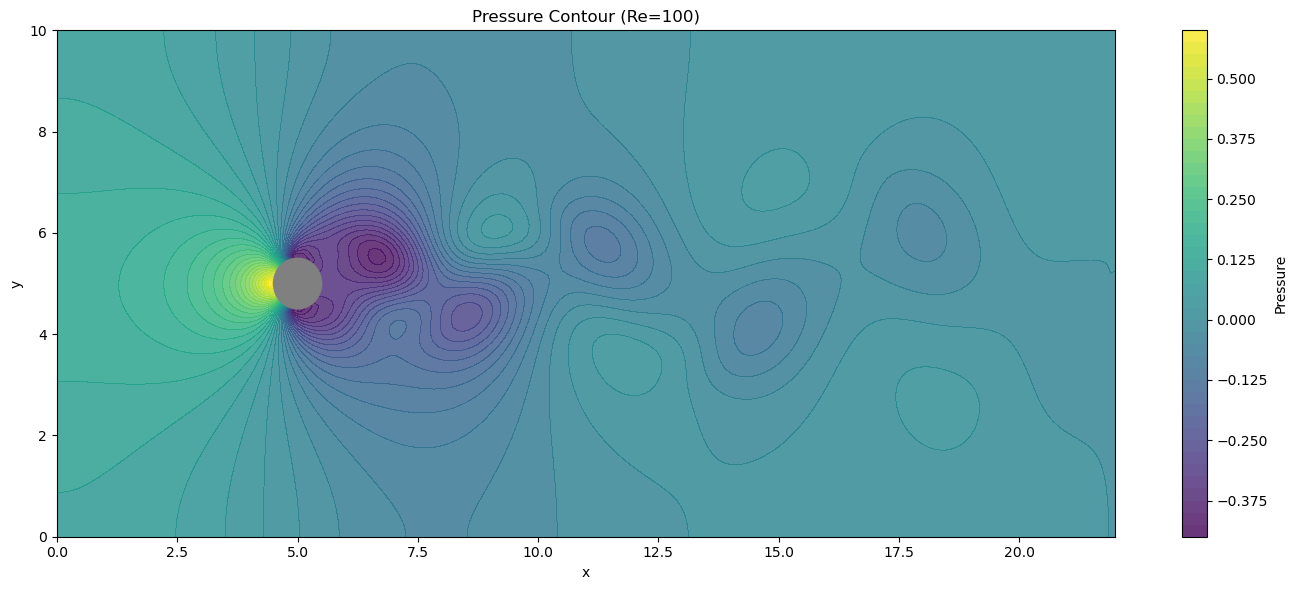

In [184]:
# Pressure contour
plt.figure(figsize=(14, 6))
plt.title(f"Pressure Contour (Re={Re})")
plt.contourf(X, Y, p, levels=50, cmap='viridis', alpha=0.8)
cylinder = plt.Circle((cx, cy), R, color='gray', zorder=5)
plt.gca().add_patch(cylinder)
plt.colorbar(label='Pressure')
plt.xlabel('x'); plt.ylabel('y')
plt.xlim(0, Lx); plt.ylim(0, Ly)
plt.tight_layout()
plt.show()

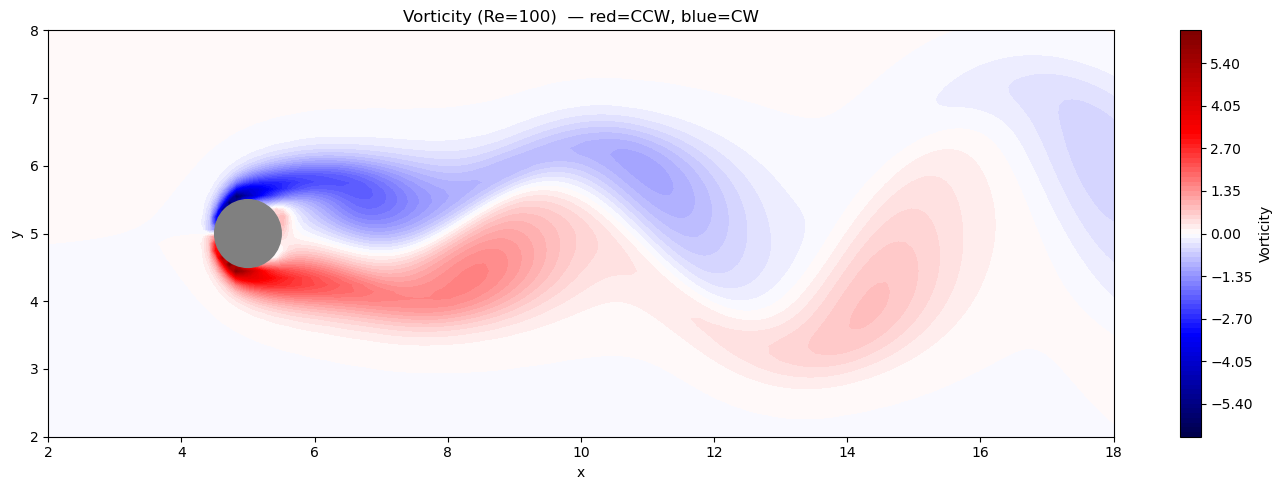

In [187]:
# Vorticity contour: omega = dv/dx - du/dy
omega = (v[1:-1, 2:] - v[1:-1, :-2]) / (2*dx) \
      - (u[2:, 1:-1] - u[:-2, 1:-1]) / (2*dy)

vlim = np.max(np.abs(omega))
plt.figure(figsize=(14, 5))
plt.title(f"Vorticity (Re={Re})  — red=CCW, blue=CW")
plt.contourf(X[1:-1, 1:-1], Y[1:-1, 1:-1], omega,
             levels=100, cmap='seismic', vmin=-vlim, vmax=vlim)
plt.gca().add_patch(plt.Circle((cx, cy), R, color='gray', zorder=5))
plt.colorbar(label='Vorticity')
plt.xlabel('x'); plt.ylabel('y')
plt.xlim(2, 18); plt.ylim(2, 8)   # zoom on wake
plt.tight_layout()
plt.show()

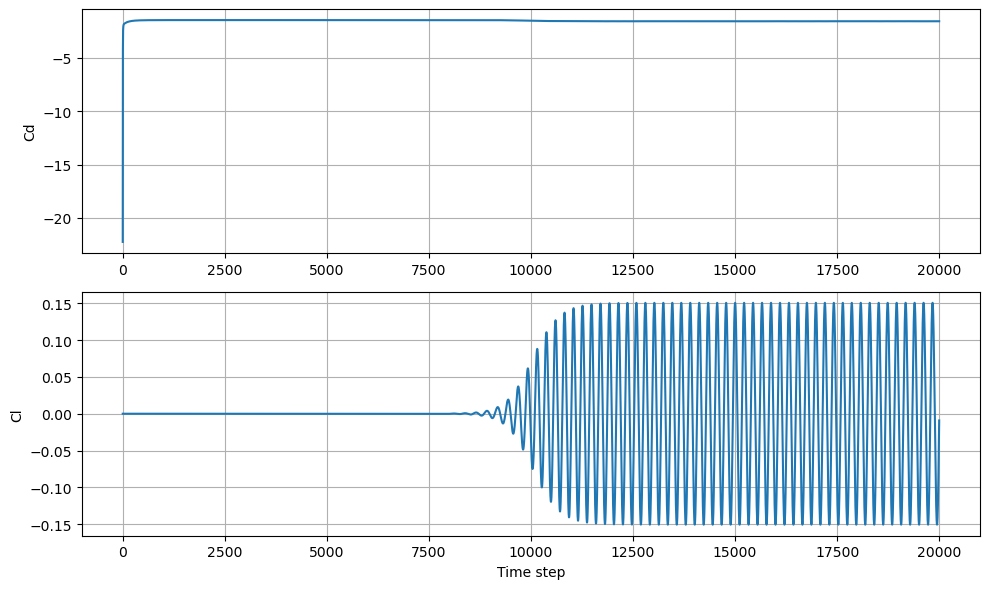

In [96]:
# Cd and Cl history
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
ax1.plot(drag_history); ax1.set_ylabel('Cd'); ax1.grid(True)
ax2.plot(lift_history); ax2.set_ylabel('Cl'); ax2.grid(True)
ax2.set_xlabel('Time step')
plt.tight_layout(); plt.show()


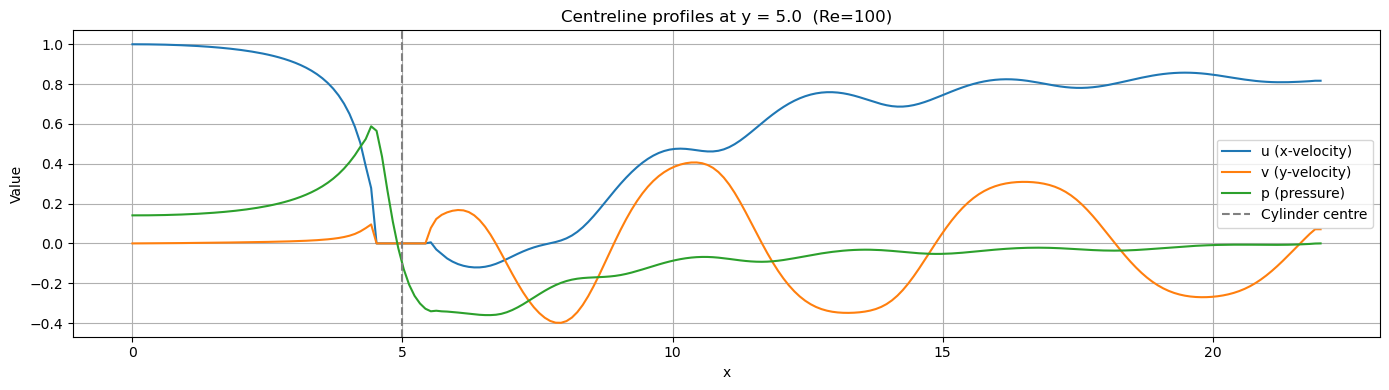

In [188]:
# Centerline profiles (y = 0.5*Ly, horizontal mid-plane)
mid = Ny // 2
plt.figure(figsize=(14, 4))
plt.plot(x, u[mid, :], label='u (x-velocity)')
plt.plot(x, v[mid, :], label='v (y-velocity)')
plt.plot(x, p[mid, :], label='p (pressure)')
plt.axvline(cx, color='gray', linestyle='--', label='Cylinder centre')
plt.title(f"Centreline profiles at y = {cy}  (Re={Re})")
plt.xlabel('x'); plt.ylabel('Value')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()